In [1]:
#Imports
import torch
import random
import os
from numpy import genfromtxt
import numpy as np
import matplotlib.pyplot as plt
import csv
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pandas as pd
import diffrax
import equinox as eqx
import jax
import jax.nn as jnn
import jax.random as jr
import optax
from tqdm import tqdm

path = os.getcwd() + "/ambr"
files = os.listdir(path)
files_xls = [f for f in files if f[-3:] == 'csv']
df = pd.DataFrame()
files_xls

df = [None] * len(files_xls)

for f in range(len(files_xls)):
    data = pd.read_csv(path + "/" + files_xls[f])

    data.columns = data.columns.str.strip()
    data.columns = data.columns.str.replace('\ufeff', '', regex=False)

    if "Time" not in data.columns:
        print(files_xls[f], data.columns.tolist())
        raise ValueError(f"No Time column in {files_xls[f]}")

    # Extract run tag from filename
    run_name = files_xls[f].replace(".csv", "")

    df[f] = data
    df[f] = df[f].loc[:, ~df[f].columns.duplicated()]
    df[f] = df[f].sort_values("Time").reset_index(drop=True)
    df[f] = df[f].drop(columns=[c for c in df[f].columns
             if ('Optical density' not in c) 
             and ('pH' not in c) 
             and ('Time' not in c)])

In [2]:
run2_5_10  = ["Time" if x == "Time" else x + " run2" for x in df[0].columns]
run1_19_24 = ["Time" if x == "Time" else x + " run1" for x in df[1].columns]
run1_13_18 = ["Time" if x == "Time" else x + " run1" for x in df[2].columns]
run2_11_16 = ["Time" if x == "Time" else x + " run2" for x in df[3].columns]
run2_17_22 = ["Time" if x == "Time" else x + " run2" for x in df[4].columns]

# List of lists, one per dataframe
new_names = [run2_5_10, run1_19_24, run1_13_18, run2_11_16, run2_17_22]

# Now assign
for d in range(len(df)):
    df[d].columns = new_names[d]

In [3]:
df_merged = df[0].copy()

for d in range(1, len(df)):
    df_merged = pd.merge(df_merged, df[d], on="Time", how="outer")

df_merged = df_merged.sort_values("Time").reset_index(drop=True)

In [4]:
path = os.getcwd() + "/Lorena_dataset/Glucose_files_310326/OfflineMetabolites_AMBR1.csv"
glucose1 = pd.read_csv(path, delimiter=';')
path = os.getcwd() + "/Lorena_dataset/Glucose_files_310326/OfflineMetabolites_AMBR2.xlsx"
glucose2 = pd.read_excel(path)


glc1 = glucose1[["Reactor","Time","Glucose"]]
glucose2.columns
glc2 = glucose2[["Reactor","Time","Glucose Vanquish"]]

In [5]:
col_to_drop = ["Bioreactor 13 - Optical density run1", "Bioreactor 13 - pH run1",
               "Bioreactor 17 - Optical density run2", "Bioreactor 17 - pH run2",
               "Bioreactor 18 - Optical density run2", "Bioreactor 18 - pH run2",
               "Bioreactor 22 - Optical density run2", "Bioreactor 22 - pH run2",
               "Bioreactor 11 - Optical density run2", "Bioreactor 11 - pH run2",
               "Bioreactor 19 - Optical density run1", "Bioreactor 19 - pH run1"]

df_merged = df_merged.drop(columns=col_to_drop)

In [6]:
glucose_df = pd.DataFrame()
bior = None

for i in range(1, len(df_merged.columns), 2):
    col = df_merged.columns[i]
    bio_name = col[:-23]
    run_tag = col[-4:]

    if "run1" in col:
        bior = glc1[glc1["Reactor"] == bio_name][["Time", "Glucose"]].copy()
        bior = bior.rename(columns={"Glucose": f"{bio_name} {run_tag}"})
    elif "run2" in col:
        bior = glc2[glc2["Reactor"] == bio_name][["Time", "Glucose Vanquish"]].copy()
        bior = bior.rename(columns={"Glucose Vanquish": f"{bio_name} {run_tag}"})

    # Rename Glucose column
    bior = bior.rename(columns={"Glucose": f"{bio_name} {run_tag}"})

    # Merge into glucose_df
    if glucose_df.empty:
        glucose_df = bior
    else:
        glucose_df = pd.merge(glucose_df, bior, on="Time", how="outer")

glucose_df = glucose_df.sort_values("Time").reset_index(drop=True)
glucose_df.columns

Index(['Time', 'Bioreactor 5 run2', 'Bioreactor 6 run2', 'Bioreactor 7 run2',
       'Bioreactor 8 run2', 'Bioreactor 9 run2', 'Bioreactor 10 run2',
       'Bioreactor 21 run1', 'Bioreactor 22 run1', 'Bioreactor 23 run1',
       'Bioreactor 24 run1', 'Bioreactor 14 run1', 'Bioreactor 15 run1',
       'Bioreactor 16 run1', 'Bioreactor 17 run1', 'Bioreactor 18 run1',
       'Bioreactor 12 run2', 'Bioreactor 13 run2', 'Bioreactor 14 run2',
       'Bioreactor 15 run2', 'Bioreactor 16 run2', 'Bioreactor 19 run2',
       'Bioreactor 20 run2', 'Bioreactor 21 run2'],
      dtype='object')

In [7]:
cols = list(df_merged.columns)
for i, col in enumerate(cols):
    if "Optical density" not in col:
        continue
    new_col_name = col.replace("Optical density", "Biomass")
    ph_col = col.replace("Optical density", "pH")
    ph_idx = df_merged.columns.get_loc(ph_col)
    df_merged.insert(ph_idx + 1, new_col_name, df_merged[col] * 0.4267)

In [8]:
#Lets start the loop to delete the NaNs !
ts_list = []
ys_list = []

for i in range(1,len(glucose_df.columns)):
    s = glucose_df[glucose_df.columns[i]].dropna()
    s1 = df_merged[df_merged.columns[1:][3*i-3:3*i][0]].dropna()
    s2 = df_merged[df_merged.columns[1:][3*i-3:3*i][1]].dropna()
    s3 = df_merged[df_merged.columns[1:][3*i-3:3*i][2]].dropna()

    ts_list.append(s.index.to_numpy(dtype=np.float32))
    ts_list.append(s1.index.to_numpy(dtype=np.float32))
    ts_list.append(s2.index.to_numpy(dtype=np.float32))
    ts_list.append(s3.index.to_numpy(dtype=np.float32))

    ys_list.append(s.to_numpy(dtype=np.float32))
    ys_list.append(s1.to_numpy(dtype=np.float32))
    ys_list.append(s2.to_numpy(dtype=np.float32))
    ys_list.append(s3.to_numpy(dtype=np.float32))


    

In [9]:
train = ys_list[:30] + ys_list[33:]
test = ys_list[31:32]

In [10]:
train_t = ts_list[:30] + ts_list[33:]
test_t = ts_list[31:32]

In [11]:
class Func(eqx.Module):
    out_scale: jax.Array
    mlp: eqx.nn.MLP

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.out_scale = jnp.array(1.0)
        self.mlp = eqx.nn.MLP(
            in_size=data_size,
            out_size=data_size,
            width_size=width_size,
            depth=depth,
            activation=jnn.softplus,
            final_activation=lambda x: x,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.out_scale * self.mlp(y)

class NeuralODE(eqx.Module):
    func: Func

    def __init__(self, data_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.func = Func(data_size, width_size, depth, key=key)

    def __call__(self, ts, y0):
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(self.func),
            diffrax.Dopri5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-4, atol=1e-6),
            adjoint=diffrax.DirectAdjoint(),
            max_steps=1000000,
            saveat=diffrax.SaveAt(ts=ts),
        )
        return solution.ys

lr = 1e-7
width_size = 64
depth = 3

def main(variable_data_list, variable_ts_list, n_epochs, seed=5678):

    key = jr.PRNGKey(seed)
    data_key, model_key, loader_key = jr.split(key, 3)

    data_size = 4

    model = NeuralODE(data_size, width_size, depth, key=model_key)
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_value_and_grad
    def grad_loss(model, ti, yi):
        y_pred = model(ti, yi[0])  # shape (T, data_size)
        sigma = 1.0
        loss_classic = jnp.mean(((yi - y_pred) / sigma) ** 2)
        negativity_loss = jnp.mean(jnp.maximum(0.0, -y_pred) ** 2)
        return loss_classic + 0.0 * negativity_loss

    @eqx.filter_jit
    def make_step(ti, yi, model, opt_state):
        loss, grads = grad_loss(model, ti, yi)
        updates, opt_state = optim.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return loss, model, opt_state

    loss_l = []
    n_vars = 4
    R2_scores = [[] for _ in range(n_vars)]

    # number of bioreactors = total entries / 4 variables each
    o = len(variable_data_list) // 4

    for epoch in tqdm(range(n_epochs)):
        idx = epoch % o

        # Get the 4 variables for this bioreactor
        glc_ys  = variable_data_list[4*idx]
        od_ys   = variable_data_list[4*idx + 1]
        ph_ys   = variable_data_list[4*idx + 2]
        bio_ys  = variable_data_list[4*idx + 3]

        # Get the corresponding time arrays
        glc_ts  = variable_ts_list[4*idx]
        od_ts   = variable_ts_list[4*idx + 1]
        ph_ts   = variable_ts_list[4*idx + 2]
        bio_ts  = variable_ts_list[4*idx + 3]

        # Use OD timestamps as the common time grid
        t = jnp.asarray(od_ts, dtype=jnp.float32)

        # Interpolate all variables onto the OD time grid
        ys = jnp.stack([
            jnp.interp(t, jnp.asarray(glc_ts), jnp.asarray(glc_ys)),  # glucose
            jnp.asarray(od_ys,  dtype=jnp.float32),                    # OD (reference)
            jnp.interp(t, jnp.asarray(ph_ts),  jnp.asarray(ph_ys)),   # pH
            jnp.interp(t, jnp.asarray(bio_ts), jnp.asarray(bio_ys)),  # biomass
        ], axis=1)  # shape (T, 4)

        y_true = torch.tensor(np.asarray(ys), dtype=torch.float32)

        loss, model, opt_state = make_step(t, ys, model, opt_state)

        y_pred = torch.tensor(np.asarray(model(t, ys[0])), dtype=torch.float32)

        loss_l.append(float(loss))

        for var_idx in range(n_vars):
            ss_res = torch.sum((y_true[:, var_idx] - y_pred[:, var_idx]) ** 2)
            ss_tot = torch.sum((y_true[:, var_idx] - torch.mean(y_true[:, var_idx])) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-12)
            R2_scores[var_idx].append(float(r2))

    return loss_l, R2_scores, t, ys, model

In [12]:
# Run
n_epochs = 100000  # Max is 240000
loss, R, t, ys, model = main(train, train_t, n_epochs)

  0%|          | 1/100000 [00:12<350:39:00, 12.62s/it]


KeyboardInterrupt: 

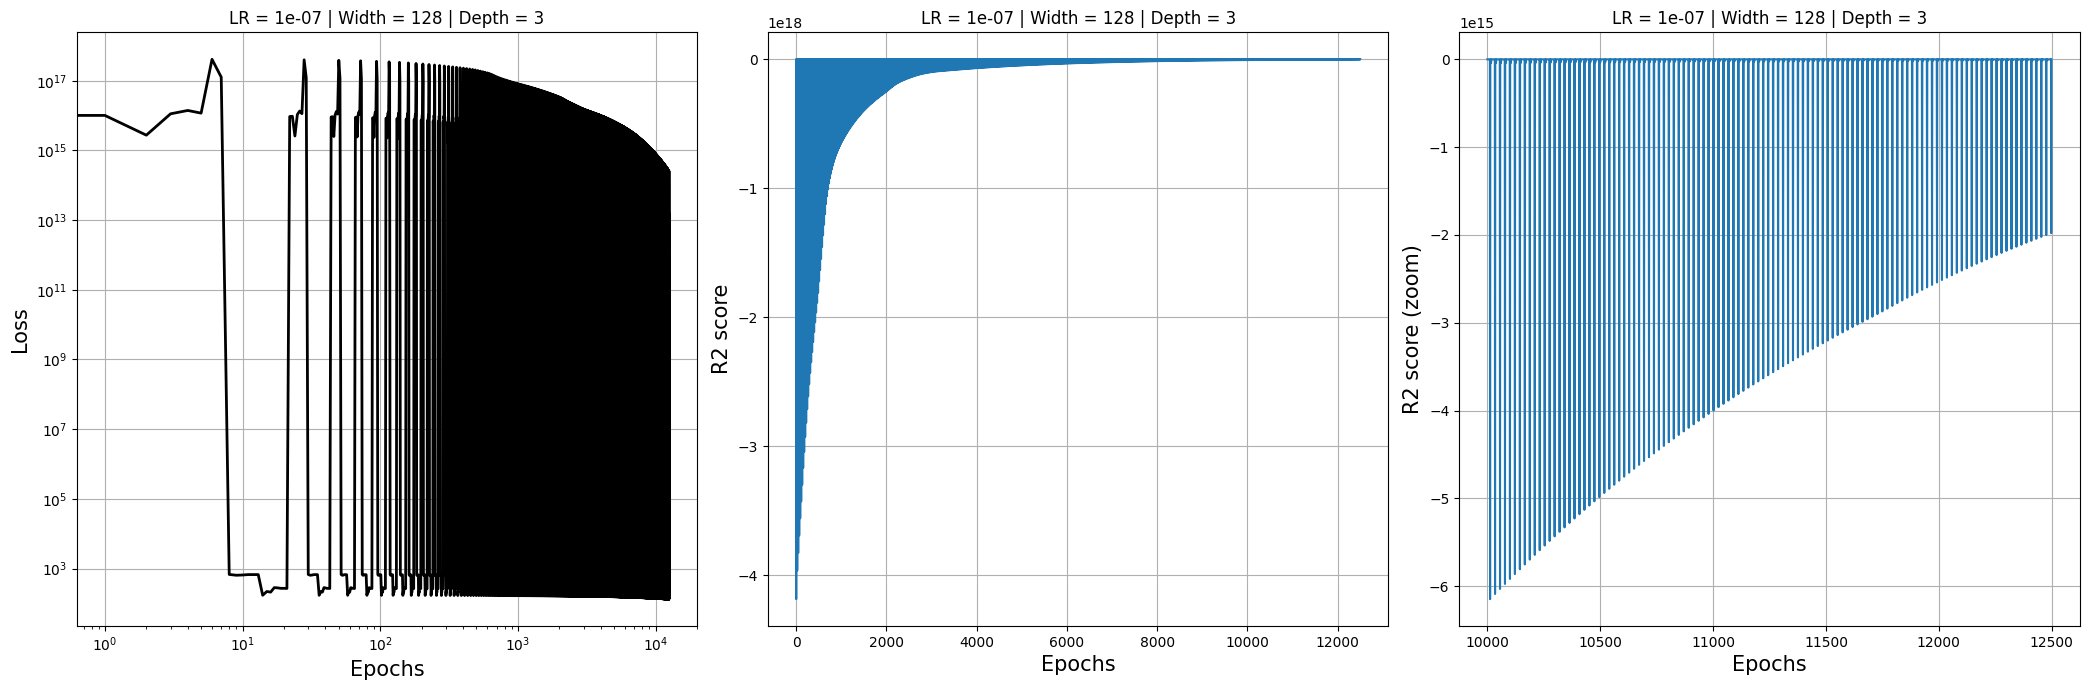

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(21, 7))

axs[0].plot(loss, color='black', linewidth=2)
axs[0].grid(True)
axs[0].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[0].set_xlabel('Epochs', fontsize=15)
axs[0].set_ylabel('Loss', fontsize=15)
axs[0].set_xscale('log')
axs[0].set_yscale('log')

start_r = int(n_epochs * 0.8)  # zoom into the last 20% of training
t_r = np.arange(start_r, n_epochs, 1)

axs[1].plot(R[0])
axs[1].grid(True)
axs[1].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[1].set_xlabel('Epochs', fontsize=15)
axs[1].set_ylabel('R2 score', fontsize=15)

axs[2].plot(t_r, R[0][start_r:])
axs[2].grid(True)
axs[2].set_title(f"LR = {lr} | Width = {width_size} | Depth = {depth}")
axs[2].set_xlabel('Epochs', fontsize=15)
axs[2].set_ylabel('R2 score (zoom)', fontsize=15)

plt.tight_layout()
plt.show()

R² Glucose: -144195092480.0000
R² OD: -5664247644160.0000
R² pH: -3778160592158720.0000
R² Biomass: -136447134793728.0000


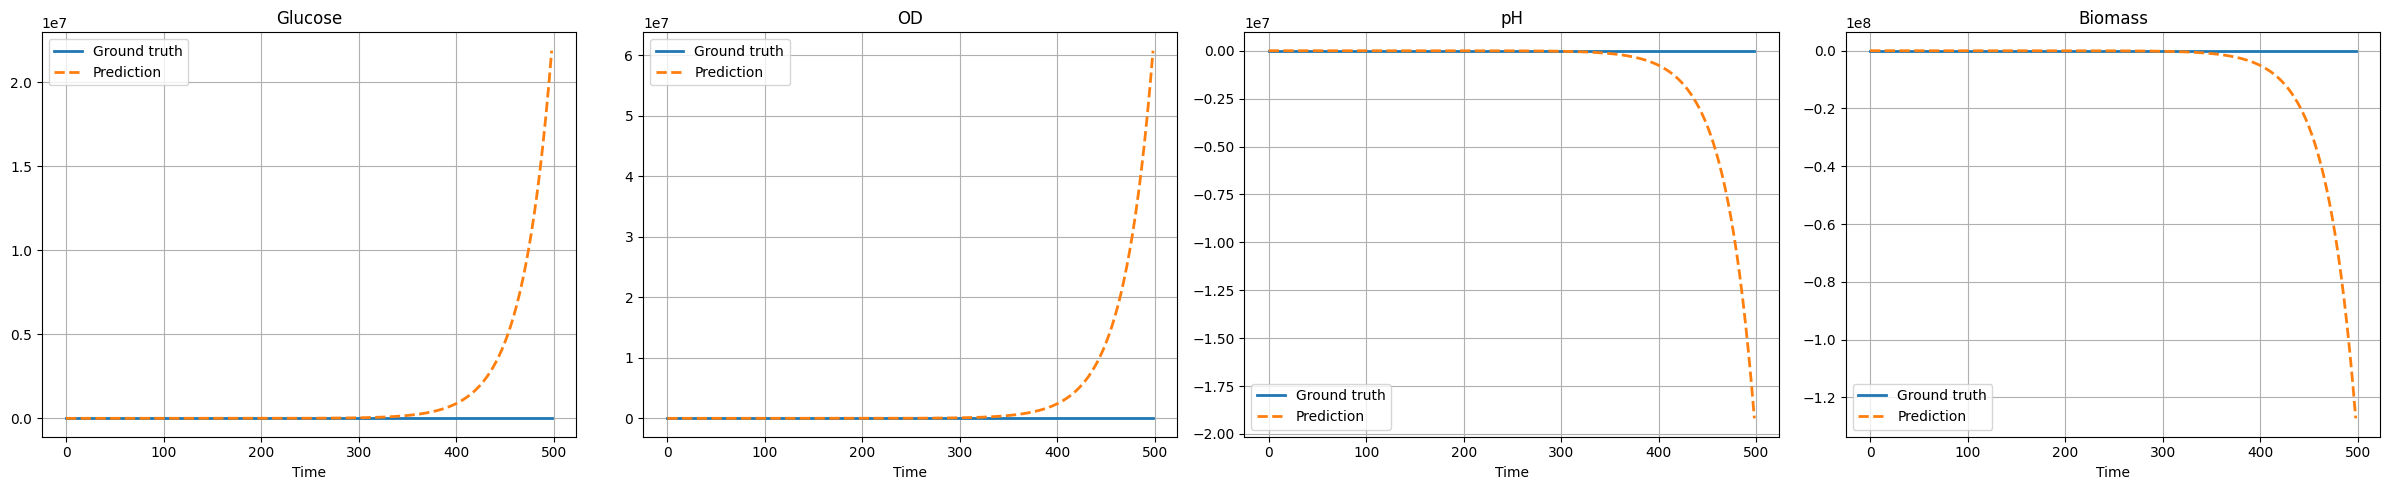

In [ ]:
test = ys_list[32:36]   # 4 entries = 1 bioreactor (glucose, OD, pH, biomass)
test_t = ts_list[32:36]

# --- Build the stacked ys and t for the test bioreactor ---
glc_ys  = test[0]
od_ys   = test[1]
ph_ys   = test[2]
bio_ys  = test[3]

glc_ts  = test_t[0]
od_ts   = test_t[1]
ph_ts   = test_t[2]
bio_ts  = test_t[3]

t_test = jnp.asarray(od_ts, dtype=jnp.float32)

ys_test = jnp.stack([
    jnp.interp(t_test, jnp.asarray(glc_ts), jnp.asarray(glc_ts)),
    jnp.asarray(od_ys,  dtype=jnp.float32),
    jnp.interp(t_test, jnp.asarray(ph_ts),  jnp.asarray(ph_ys)),
    jnp.interp(t_test, jnp.asarray(bio_ts), jnp.asarray(bio_ys)),
], axis=1)  # shape (T, 4)

# --- Run the model from the first time point ---
y_pred_test = model(t_test, ys_test[0])  # shape (T, 4)

# --- Compute R2 for each variable ---
y_true_test = torch.tensor(np.asarray(ys_test), dtype=torch.float32)
y_pred_test_torch = torch.tensor(np.asarray(y_pred_test), dtype=torch.float32)

var_names = ["Glucose", "OD", "pH", "Biomass"]
for var_idx, name in enumerate(var_names):
    ss_res = torch.sum((y_true_test[:, var_idx] - y_pred_test_torch[:, var_idx]) ** 2)
    ss_tot = torch.sum((y_true_test[:, var_idx] - torch.mean(y_true_test[:, var_idx])) ** 2)
    r2 = 1 - ss_res / (ss_tot + 1e-12)
    print(f"R² {name}: {r2:.4f}")

# --- Plot predictions vs ground truth ---
fig, axs = plt.subplots(1, 4, figsize=(24, 5))
for var_idx, name in enumerate(var_names):
    axs[var_idx].plot(t_test, ys_test[:, var_idx], label="Ground truth", linewidth=2)
    axs[var_idx].plot(t_test, y_pred_test[:, var_idx], label="Prediction", linewidth=2, linestyle="--")
    axs[var_idx].set_title(name)
    axs[var_idx].set_xlabel("Time")
    axs[var_idx].legend()
    axs[var_idx].grid(True)

plt.tight_layout()
plt.show()